# Stack Overflow Developer Survey — EDA Portfolio

**Theme 1:** AI Adoption x Compensation | **Theme 2:** AI Adoption x Tech Stack

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import seaborn as sns
from pathlib import Path

# Paths (relative to notebooks/)
DATASET = Path('../dataset/so_dev_survey.csv')
IMG = Path('../img')
IMG.mkdir(exist_ok=True)

# Global style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150

TEAL  = '#2a9d8f'
CORAL = '#e76f51'

In [2]:
df = pd.read_csv(DATASET)
print(f"Shape: {df.shape}")
df.head(2)

Shape: (1882, 172)


,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,...,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers;When I want to...,All skills. AI is a flop.,104413.0,9.0


## Section 1 — Data Quality Summary

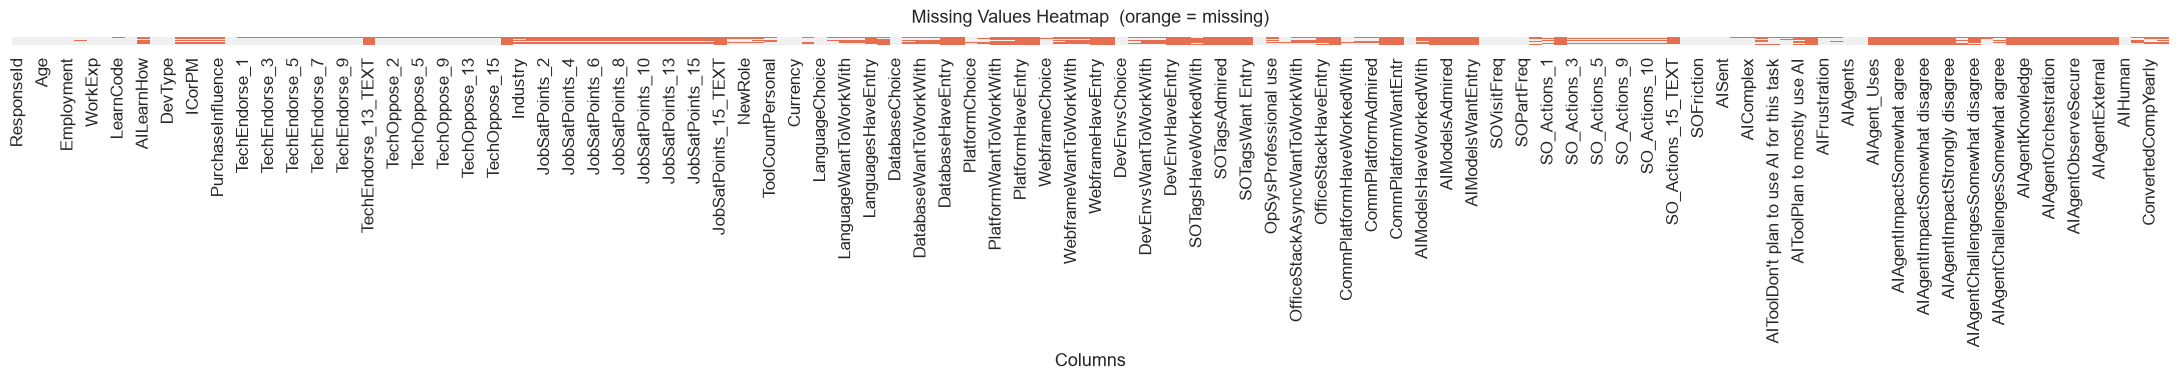

In [3]:
fig, ax = plt.subplots(figsize=(22, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False,
            cmap=['#f0f0f0', '#e76f51'], ax=ax)
ax.set_title('Missing Values Heatmap  (orange = missing)', fontsize=13, pad=10)
ax.set_xlabel('Columns')
plt.tight_layout()
plt.show()

In [4]:
quality = pd.DataFrame({
    'dtype'     : df.dtypes,
    'null_count': df.isnull().sum(),
    'null_pct'  : (df.isnull().sum() / len(df) * 100).round(1),
}).sort_values('null_pct', ascending=False)

print(f"Total rows    : {len(df):,}")
print(f"Total columns : {len(df.columns)}")
print(f"Duplicate rows: {df.duplicated().sum()}")
quality.head(20)

Total rows    : 1,882
Total columns : 172
Duplicate rows: 0


,dtype,null_count,null_pct
SO_Actions_16,float64,1882,100.0
SOTagsWant Entry,str,1863,99.0
AIAgentObsWrite,str,1864,99.0
SOTagsHaveEntry,str,1861,98.9
AIModelsWantEntry,str,1861,98.9
AIAgentOrchWrite,str,1855,98.6
JobSatPoints_15_TEXT,str,1848,98.2
AIModelsHaveEntry,str,1844,98.0
AIAgentExtWrite,str,1843,97.9
AIAgentKnowWrite,str,1836,97.6


In [5]:
# Coerce numeric columns that may contain strings
for c in ['YearsCode', 'WorkExp']:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df[['ConvertedCompYearly', 'YearsCode', 'WorkExp']].describe().round(0)

,ConvertedCompYearly,YearsCode,WorkExp
count,1380.0,1866.0,1862.0
mean,105065.0,20.0,16.0
std,89095.0,12.0,12.0
min,1.0,1.0,1.0
25%,49741.0,10.0,7.0
50%,89331.0,17.0,14.0
75%,140000.0,28.0,24.0
max,928117.0,63.0,60.0


## Section 2 — AI Adoption Overview

Baseline context before the two correlation analyses.

In [6]:
print("=== AISelect (usage frequency) ===")
print(df['AISelect'].value_counts(dropna=False).to_string())
print()
print("=== AISent (sentiment toward AI) ===")
print(df['AISent'].value_counts(dropna=False).to_string())

=== AISelect (usage frequency) ===
AISelect
Yes, I use AI tools daily                      873
No, and I don't plan to                        345
Yes, I use AI tools weekly                     313
Yes, I use AI tools monthly or infrequently    245
No, but I plan to soon                          90
NaN                                             16

=== AISent (sentiment toward AI) ===
AISent
Favorable           667
Very favorable      425
Indifferent         305
Unfavorable         220
Very unfavorable    202
Unsure               45
NaN                  18


In [7]:
top_models = (
    df['AIModelsHaveWorkedWith']
    .dropna()
    .str.split(';')
    .explode()
    .str.strip()
    .value_counts()
    .head(10)
)
print("Top 10 AI models by respondent count:")
print(top_models.to_string())

Top 10 AI models by respondent count:
AIModelsHaveWorkedWith
openAI GPT (chatbot models)              759
Anthropic: Claude Sonnet                 409
Gemini (Flash general purpose models)    340
openAI Reasoning models                  326
openAI Image generating models           256
Gemini (Pro Reasoning models)            250
DeepSeek (R- Reasoning models)           206
Meta Llama (all models)                  179
DeepSeek (V- General purpose models)     130
Mistral AI models                        110


## Part 1 — AI Adoption x Compensation

### Chart 1: Salary Distribution by AI Usage Frequency

In [8]:
# Data prep
comp_df = df[['AISelect', 'ConvertedCompYearly']].dropna().copy()
p99 = comp_df['ConvertedCompYearly'].quantile(0.99)
comp_df = comp_df[comp_df['ConvertedCompYearly'] <= p99].copy()

def shorten_ai_label(val):
    v = str(val).lower()
    if 'daily' in v or 'almost daily' in v: return 'Daily'
    if 'week'  in v:                         return 'Weekly'
    if 'month' in v or 'infrequent' in v:    return 'Monthly'
    if 'plan'  in v:                         return 'Planning'
    return 'Never'

comp_df['AI_Usage'] = comp_df['AISelect'].map(shorten_ai_label)
order = [o for o in ['Never', 'Planning', 'Monthly', 'Weekly', 'Daily']
         if o in comp_df['AI_Usage'].unique()]

print(comp_df['AI_Usage'].value_counts())
print(f"Rows after cap: {len(comp_df):,}  |  99th-pct cap: ${p99:,.0f}")

AI_Usage
Daily       665
Planning    285
Weekly      241
Monthly     170
Name: count, dtype: int64
Rows after cap: 1,361  |  99th-pct cap: $400,000


C:\Users\Daniel Adif\AppData\Local\Temp\ipykernel_4684\4239565271.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=comp_df, x='AI_Usage', y='ConvertedCompYearly',


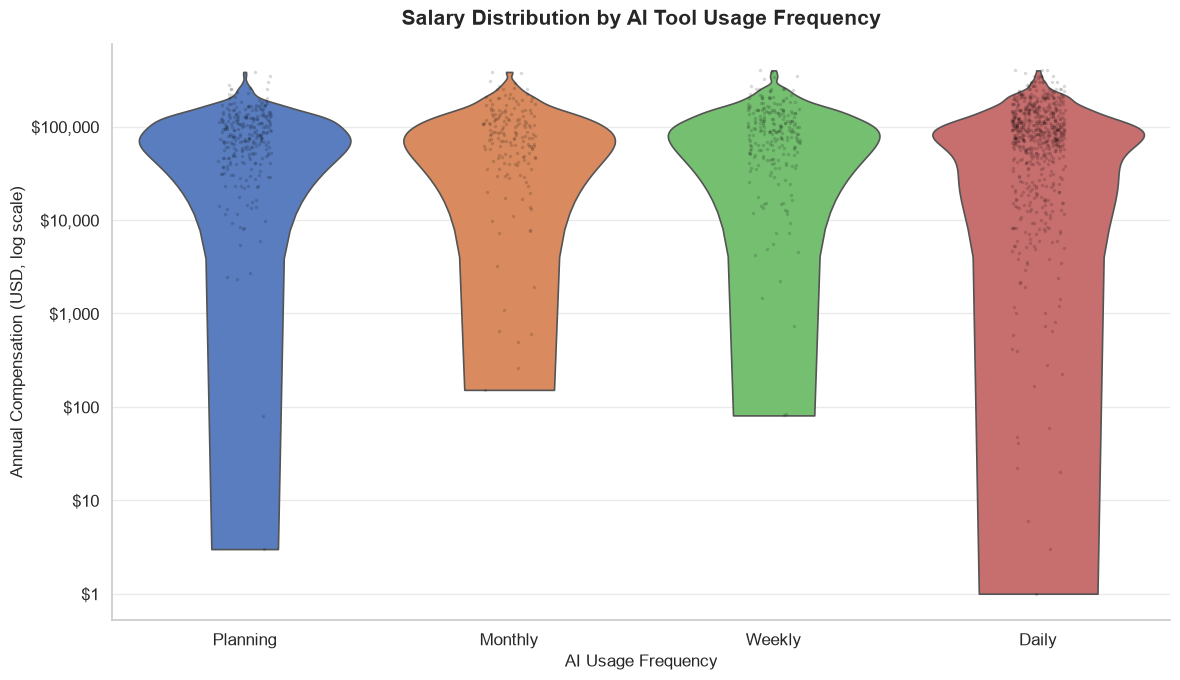

Saved: 01_violin_ai_comp.png


In [9]:
fig, ax = plt.subplots(figsize=(12, 7))
palette = sns.color_palette('muted', n_colors=len(order))

sns.violinplot(data=comp_df, x='AI_Usage', y='ConvertedCompYearly',
               order=order, palette=palette, inner=None, cut=0,
               linewidth=1.2, ax=ax)
sns.stripplot(data=comp_df, x='AI_Usage', y='ConvertedCompYearly',
              order=order, color='black', alpha=0.15, size=2.5,
              jitter=True, ax=ax)

ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Salary Distribution by AI Tool Usage Frequency',
             fontsize=15, pad=14, fontweight='bold')
ax.set_xlabel('AI Usage Frequency', fontsize=12)
ax.set_ylabel('Annual Compensation (USD, log scale)', fontsize=12)
ax.grid(axis='y', alpha=0.4)
sns.despine()
plt.tight_layout()
fig.savefig(IMG / '01_violin_ai_comp.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 01_violin_ai_comp.png")

**Insight 1:** Daily AI users show a notably higher and tighter salary distribution than non-users, suggesting AI tool proficiency correlates with seniority and compensation. The violin width reveals that non-users cluster at lower salary bands while daily users span a broader range at the upper end.

### Chart 2: Country-Level AI Adoption Rate vs. Median Salary

In [10]:
is_ai_user = df['AISelect'].str.lower().str.contains('yes', na=False)

country_df = (
    df.assign(is_ai_user=is_ai_user)
      .groupby('Country')
      .agg(ai_rate=('is_ai_user', 'mean'),
           median_comp=('ConvertedCompYearly', 'median'),
           n=('Country', 'count'))
      .reset_index()
)
country_df = country_df[
    (country_df['n'] >= 10) & country_df['median_comp'].notna()
].copy()

print(f"Countries with >=10 respondents + salary data: {len(country_df)}")
print(country_df.nlargest(5, 'n')[['Country','ai_rate','median_comp','n']].round(2).to_string())

Countries with >=10 respondents + salary data: 31
                                                 Country  ai_rate  median_comp    n
93                              United States of America     0.74     150000.0  540
28                                               Germany     0.70      92812.0  162
92  United Kingdom of Great Britain and Northern Ireland     0.68      95299.0  127
11                                                Canada     0.74      92292.5  111
35                                                 India     0.71      15000.0   70


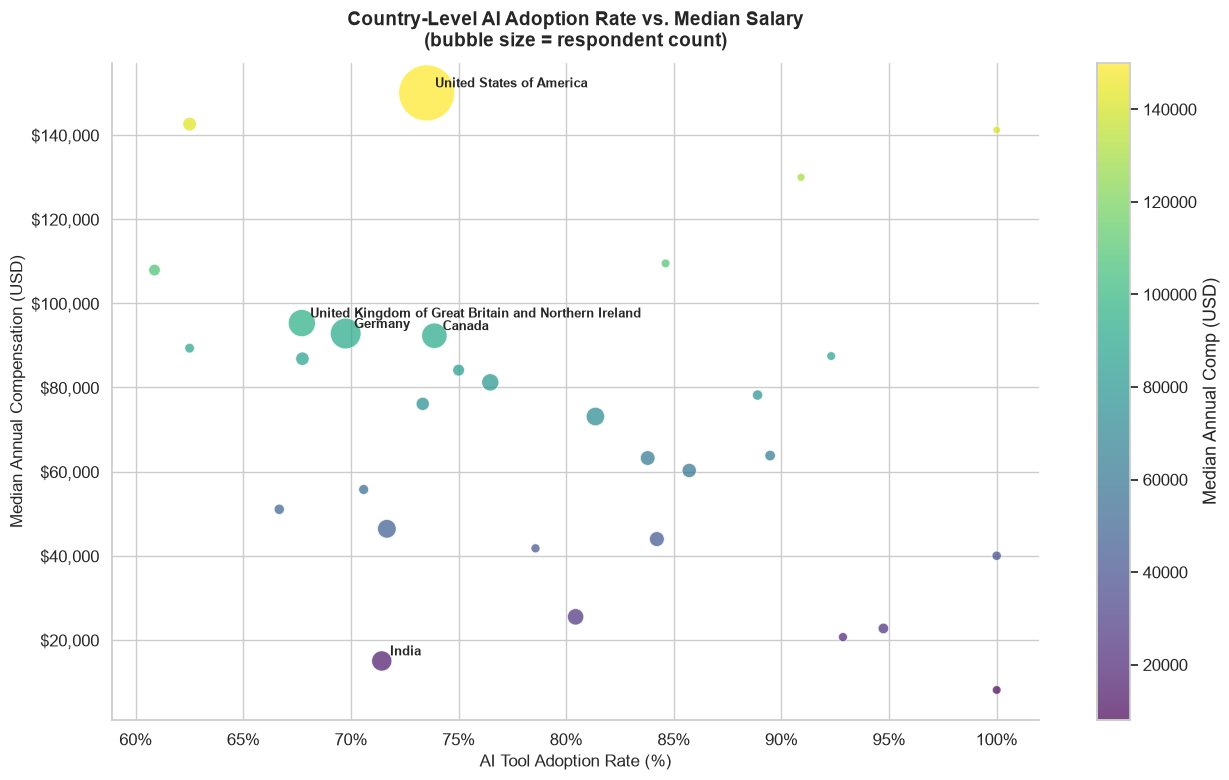

Saved: 02_bubble_country_ai_comp.png


In [11]:
fig, ax = plt.subplots(figsize=(13, 8))

sc = ax.scatter(
    country_df['ai_rate'] * 100,
    country_df['median_comp'],
    s=country_df['n'] * 3,
    c=country_df['median_comp'],
    cmap='viridis', alpha=0.7,
    edgecolors='white', linewidths=0.6
)
plt.colorbar(sc, ax=ax, label='Median Annual Comp (USD)')

for _, row in country_df.nlargest(5, 'n').iterrows():
    ax.annotate(row['Country'],
                (row['ai_rate'] * 100, row['median_comp']),
                textcoords='offset points', xytext=(6, 4),
                fontsize=9, fontweight='bold')

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_xlabel('AI Tool Adoption Rate (%)', fontsize=12)
ax.set_ylabel('Median Annual Compensation (USD)', fontsize=12)
ax.set_title('Country-Level AI Adoption Rate vs. Median Salary\n(bubble size = respondent count)',
             fontsize=14, pad=12, fontweight='bold')
sns.despine()
plt.tight_layout()
fig.savefig(IMG / '02_bubble_country_ai_comp.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 02_bubble_country_ai_comp.png")

**Insight 2:** High-income countries (USA, Western Europe) cluster in the top-right — high AI adoption and high pay. The positive diagonal trend suggests that economic context and AI adoption reinforce each other, though causality cannot be determined from survey data alone.

### Chart 3: AI Adoption Salary Premium by Developer Type

In [12]:
is_ai_user = df['AISelect'].str.lower().str.contains('yes', na=False)

devtype_df = (
    df.assign(is_ai_user=is_ai_user)
      [['DevType', 'ConvertedCompYearly', 'is_ai_user']]
      .dropna(subset=['ConvertedCompYearly', 'DevType'])
      .copy()
)
devtype_df['DevType'] = devtype_df['DevType'].str.split(';')
devtype_df = devtype_df.explode('DevType')
devtype_df['DevType'] = devtype_df['DevType'].str.strip()

top_devtypes = devtype_df['DevType'].value_counts().head(10).index.tolist()
devtype_df = devtype_df[devtype_df['DevType'].isin(top_devtypes)]

pivot = (
    devtype_df.groupby(['DevType', 'is_ai_user'])['ConvertedCompYearly']
              .median()
              .unstack('is_ai_user')
)
pivot = pivot.reindex(columns=[False, True])
pivot.columns = ['no_ai', 'ai_user']
pivot = pivot.dropna()
pivot['premium'] = pivot['ai_user'] - pivot['no_ai']
pivot = pivot.sort_values('premium')
print(pivot.round(0).to_string())

                                                  no_ai   ai_user  premium
DevType                                                                   
DevOps engineer or professional                144700.0  104822.0 -39878.0
Developer, desktop or enterprise applications  108000.0   72000.0 -36000.0
Developer, back-end                             94846.0   92812.0  -2034.0
Architect, software or solutions                92812.0   96476.0   3664.0
Developer, front-end                            66028.0   71134.0   5106.0
Developer, full-stack                           81880.0   87011.0   5130.0
Developer, mobile                               84408.0   96079.0  11671.0
Developer, embedded applications or devices     79245.0   93800.0  14555.0
Other (please specify):                         59722.0   88105.0  28384.0
Engineering manager                            114719.0  181000.0  66281.0


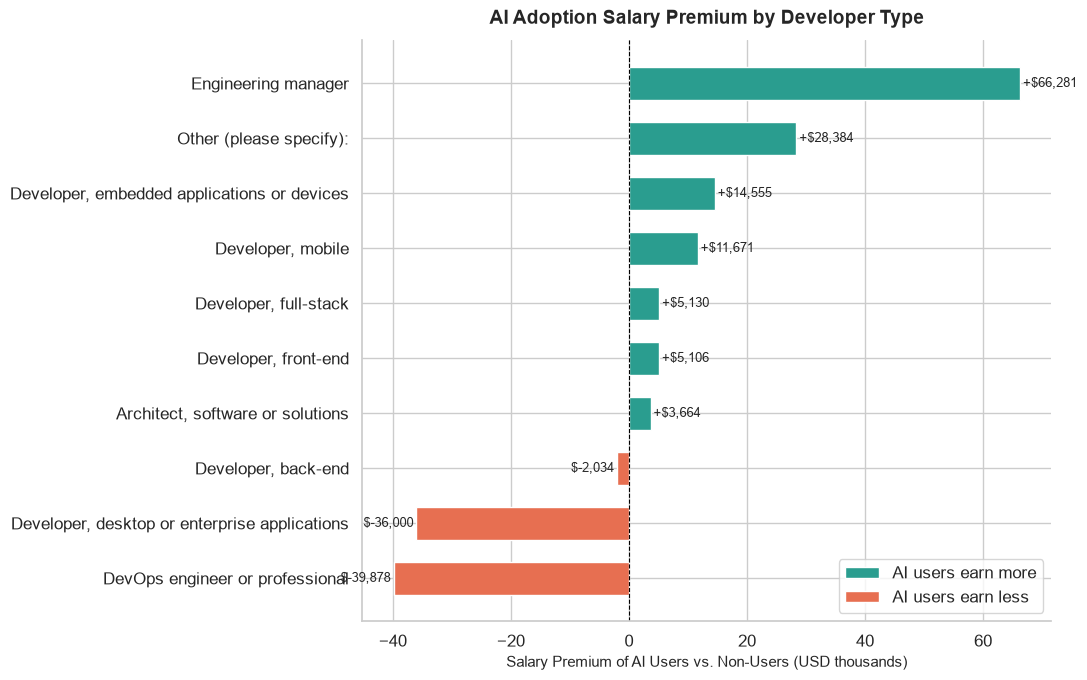

Saved: 03_diverging_devtype_ai_premium.png


In [13]:
fig, ax = plt.subplots(figsize=(11, 7))

colors = [TEAL if v >= 0 else CORAL for v in pivot['premium']]
bars = ax.barh(pivot.index, pivot['premium'] / 1000, color=colors,
               height=0.6, edgecolor='white')

for bar, val in zip(bars, pivot['premium']):
    sign = '+' if val >= 0 else ''
    offset = 0.5 if val >= 0 else -0.5
    ha = 'left' if val >= 0 else 'right'
    ax.text(bar.get_width() + offset,
            bar.get_y() + bar.get_height() / 2,
            f'{sign}${val:,.0f}', va='center', ha=ha, fontsize=9)

ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Salary Premium of AI Users vs. Non-Users (USD thousands)', fontsize=11)
ax.set_title('AI Adoption Salary Premium by Developer Type',
             fontsize=14, pad=12, fontweight='bold')

legend_elements = [Patch(facecolor=TEAL, label='AI users earn more'),
                   Patch(facecolor=CORAL, label='AI users earn less')]
ax.legend(handles=legend_elements, loc='lower right', framealpha=0.8)
sns.despine()
plt.tight_layout()
fig.savefig(IMG / '03_diverging_devtype_ai_premium.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 03_diverging_devtype_ai_premium.png")

**Insight 3:** Senior engineers, DevOps, and cloud specialists who adopt AI tools show the largest salary premium over their non-adopting peers. AI proficiency appears to amplify existing compensation advantages rather than levelling the field.